# pyCrossTalkeR Example - Human Myelofibrosis

## Cell-Cell Communication Analysis of Human Myelofibrosis scRNA-seq Data Using pyCrossTalkeR

Here, we demonstrate the usage of pyCrossTalkeR on the case study Myelofibrosis scRNA-seq data set from the paper. The predicted ligand-receptor interactions used in this tutorial are provided within this package. These differ sightly from the results presented in the paper, since they were recomputed using the cellphoneDB Method with the liana package and the consensus interaction database.

The scRNA-seq data contains two conditions: control (CTR_LR.csv) and disease condition (EXP_LR.csv). We show how to execute pyCrossTalkeR and finally go over some of the results, that are also provided inside the resulting pyCrossTalkeR report.

### Running pyCrossTalkeR

First, we need to import the pyCrossTalkeR libraries (tools and plots). Next, we define a named list of either the paths to the Ligand-Receptor interaction tables, or directly dataframe objects for each condition of interest. Please note that it is possible to run pyCrossTalkeR with more than two conditions. Here we load the files from within the package. We can further define a path where we like to save our results (output) and run pyCrossTalkeR with the `analise_LR()` function from the `generate_report.py` file:

In [1]:
from pycrosstalker import tools as cttl
from pycrosstalker import plots as ctpl
import pandas as pd
import matplotlib.pyplot as plt
import os
import seaborn as sns
import numpy as np
import plotly
plotly.offline.init_notebook_mode()

In [2]:
paths = {
    'CTR': "./rawdata/CTR_LR.csv",
    'EXP': "./rawdata/EXP_LR.csv"
}
output = "output/Myelofibrosis_example"
if not os.path.isdir(output):
    os.mkdir(output)
adata = cttl.analise_LR(paths, out_path=output, filename="Myelofibrosis_example")

Create a Differential Table


Calculating CCI Ranking
Calculating GCI Ranking
Network Analysis Done
Generating h5ad file with Analysed Results


Besides passing the paths to the interaction tables and the output folder, we here also define: `out_file` - A suffix for the result reports; `output_fmt` - The file type of the result reports. As result of the successful execution, we receive two pickle objects (LR_data.pkl and LR_data_final.pkl). The LR_data_final.pkl contains all results produced by pyCrossTalkeR. Additionally, the method also returns a lrobject, which can be stored in a variable (here, `data`). It is possible to load the results of the pyCrossTalkeR analysis from the “LR_data_final.pkl" file or from the `data` variable and produce the plots separately. In the following we are going to take a look at different results within the two reports, step by step.

### Single Condition Report

The first report contains the results for each analysed condition considered separately. In our case in each section is a plot for the control condition (CTR) and the disease condition (EXP). There are two main sections in the report. The first one only deals with cell-cell-interactions and the second with cell-gene-interactions, which here means an analysis at the ligand and receptor gene level.

#### Cell-Cell-Interaction Analysis Results

The cell-cell-interaction (CCI) graph plots focus on the interactions between the different cell types within the data. We focus on three measures inside this plot:

1. Percentage of interactions indicated by the opacity of the arrows
2. Edge weight (sum of single L-R interaction scores between cell type pairs) indicated by the edge color
3. Pagerank (Node importance) indicated by the node size

After loading the result data from the previous section, we can plot the cell-cell interactions with the `plot_cci()` function. Here we show a plot for each analysed condition:

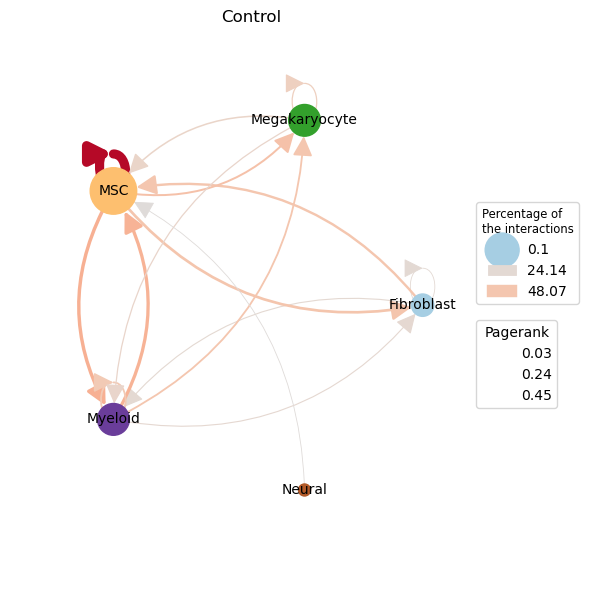

In [3]:
ctpl.plot.plot_cci(graph=adata.uns['pycrosstalker']['results']["graphs"]["CTR"],
        colors=adata.uns['pycrosstalker']['results']["colors"],
        plt_name='Control',
        coords=adata.uns['pycrosstalker']['results']["coords"],
        emax= None,
        leg= False,
        low= 0,
        high= 0, 
        ignore_alpha= False,
        log= False,
        efactor= 6,
        vfactor= 12, 
        pg= adata.uns['pycrosstalker']['results']["rankings"]["CTR"]["Pagerank"],
        scale_factor=2.0,
        node_size= 2.5,
        )


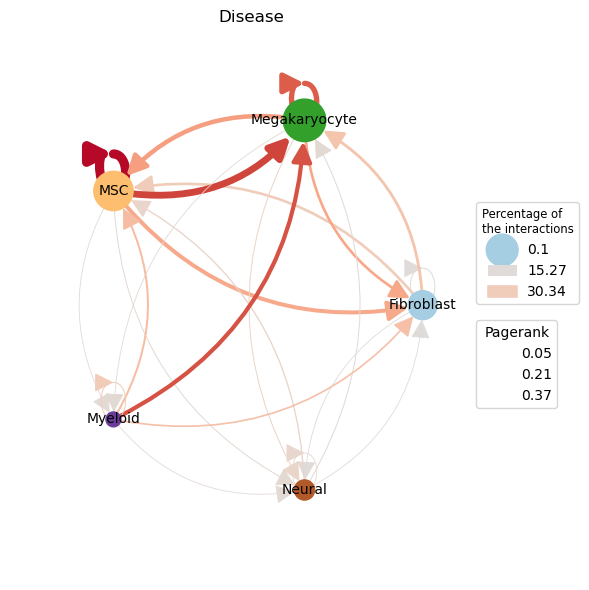

In [4]:
ctpl.plot.plot_cci(graph=adata.uns['pycrosstalker']['results']["graphs"]["EXP"],
        colors=adata.uns['pycrosstalker']['results']["colors"],
        plt_name='Disease',
        coords=adata.uns['pycrosstalker']['results']["coords"],
        emax= None,
        leg= False,
        low= 0,
        high= 0, 
        ignore_alpha= False,
        log= False,
        efactor= 6,
        vfactor= 12, 
        pg= adata.uns['pycrosstalker']['results']["rankings"]["EXP"]["Pagerank"],
        scale_factor=2.0,
        node_size= 2.5,
        )

In the control plot we can see that a high proportion of interactions are MSCs talking with themselves as well as MSC and Fibroblasts talking with each other. These interaction have also a higher weight, as can be seen by the edge color. The most important node by pagerank is the MSC node. When analysing the plot of the disease condition, we see again a high proportions of interactions are self-talking MSCs and the most important node by pagerank is again the MSC node. Here the MSC are talking more to Megakaryocytes. To really compare the two conditions we recommend using the Comparative report results.

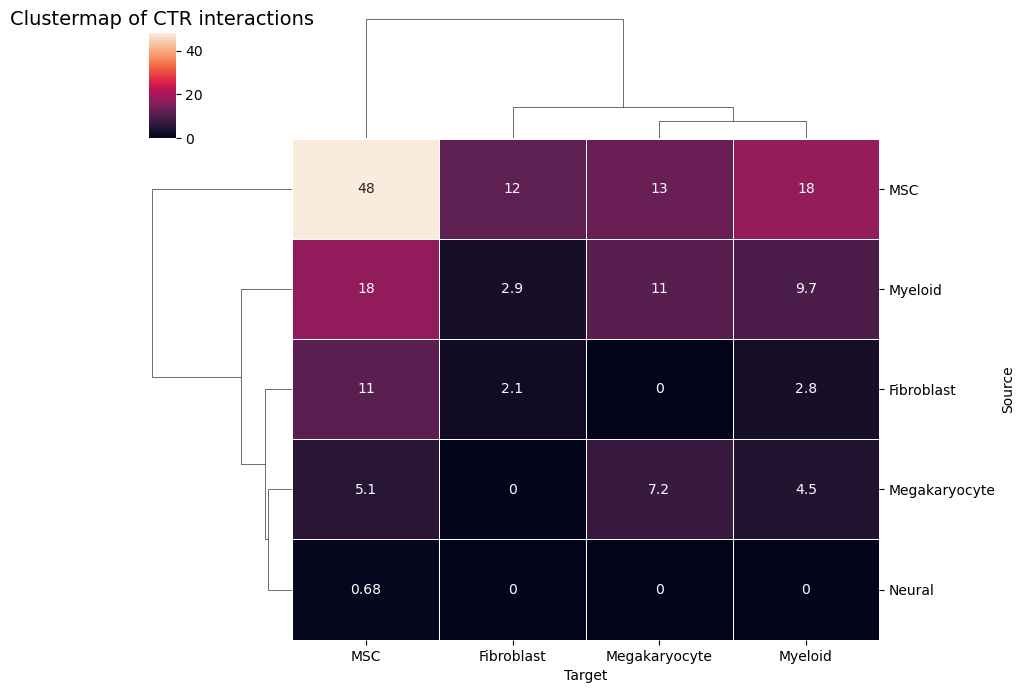

In [5]:
ctpl.plot_clustermap(adata.uns['pycrosstalker']['results']['tables']['CTR'], title="Clustermap of CTR interactions")

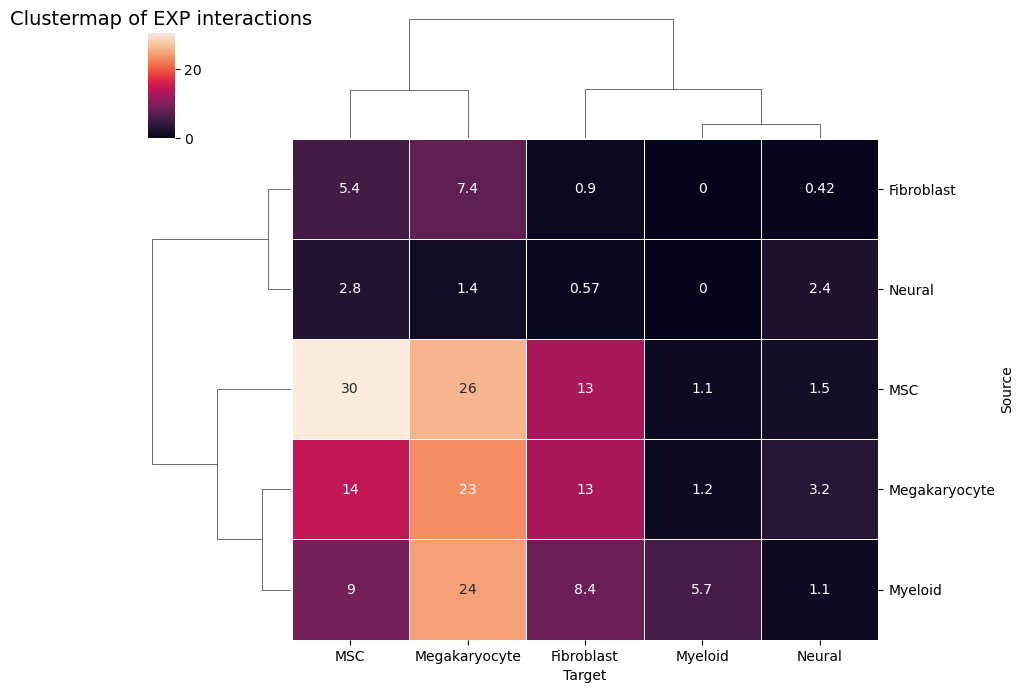

In [6]:
ctpl.plot_clustermap(adata.uns['pycrosstalker']['results']['tables']['EXP'], title="Clustermap of EXP interactions")

#### Analysis on the Gene-Cell Interation Level

We provide several different possibilities to analyse the ligand-receptor interactions on the gene level. In CrossTalkeR, topological network measures are calculated for each node(gene) in the build networks. These measures include Influencer (depending on outgoing edges), Listener(depending on incoming edges), Mediator (depending on outgoing and incoming edges), and Pagerank (overall importance) rankings. The ligand and receptors can be ranked by these measures and we can identify possibly relevant genes by considering the top genes of the rankings. In the report we provide an interactive table with all the rankings for each gene in the network. Here is an example for the top 10 genes in the Pagerank ranking for both preset conditions in form of Barplots:

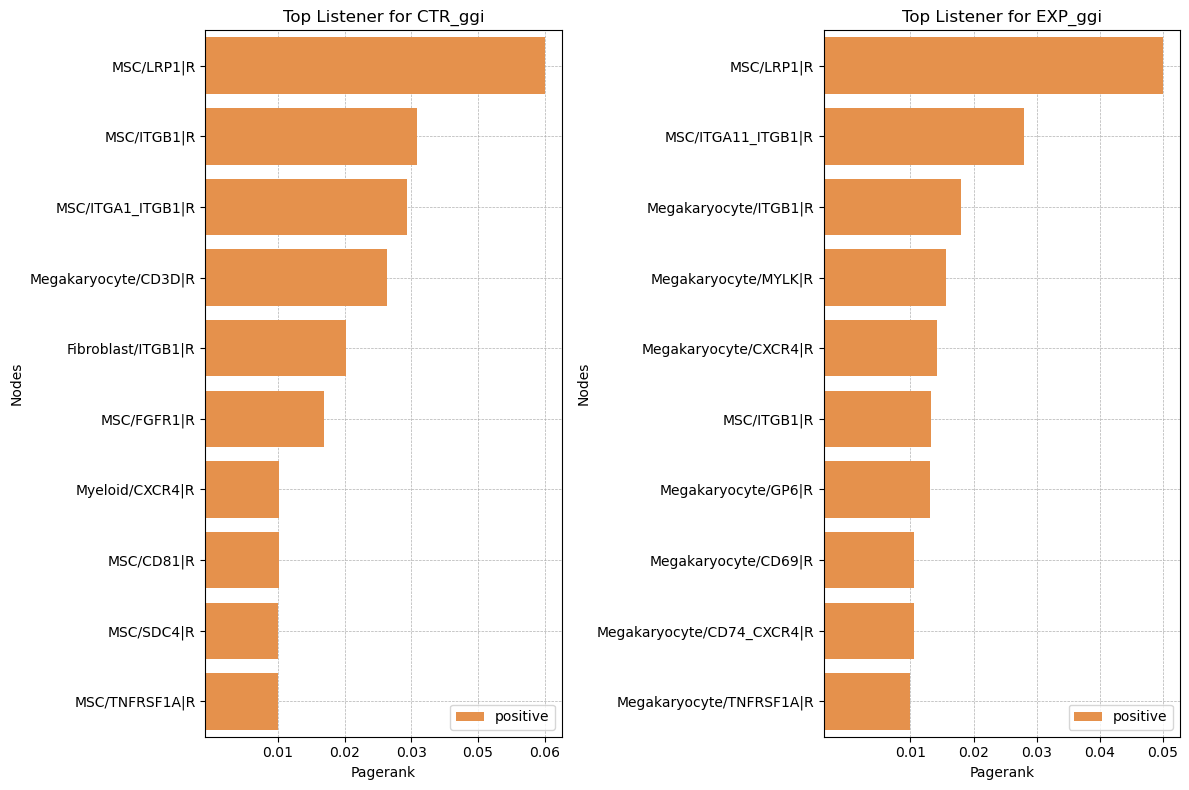

In [7]:
rankings_table_ctr = adata.uns['pycrosstalker']['results']['rankings']['CTR_ggi']
rankings_table_ctr = rankings_table_ctr.sort_values(by='Pagerank')
rankings_table_ctr['signal'] = ['negative' if x < 0 else 'positive' for x in rankings_table_ctr['Pagerank']]

rankings_table_ctr_tail = rankings_table_ctr[-10:]

rankings_table_exp = adata.uns['pycrosstalker']['results']['rankings']['EXP_ggi']
rankings_table_exp = rankings_table_exp.sort_values(by='Pagerank')
rankings_table_exp['signal'] = ['negative' if x < 0 else 'positive' for x in rankings_table_exp['Pagerank']]

rankings_table_exp_tail = rankings_table_exp[-10:]

#Plot
custom_palette = {'positive': '#FF8E32', 'negative':'#ff3e3e'}  # Orange and Blue
fig, axes = plt.subplots(1, 2, figsize=(12, 8), sharey=False)  # 1 row, 2 columns

sns.barplot(x='Pagerank', y='nodes', data=rankings_table_ctr_tail, hue='signal', dodge=False, palette=custom_palette, ax=axes[0])
axes[0].set_title('Top Listener for CTR_ggi')
axes[0].set_xlabel('Pagerank')
axes[0].set_ylabel('Nodes')

sns.barplot(x='Pagerank', y='nodes', data=rankings_table_exp_tail, hue='signal', dodge=False, palette=custom_palette, ax=axes[1])
axes[1].set_title("Top Listener for EXP_ggi")
axes[1].set_xlabel('Pagerank')
axes[1].set_ylabel('Nodes')

# Set x-axis tick intervals
max_val = rankings_table_ctr_tail['Pagerank'].max()
min_val = rankings_table_ctr_tail['Pagerank'].min()
ticks = np.linspace(min_val, max_val, num=5)  # Adjust 'num' for more/less intervals
axes[0].set_xticks(ticks, [f'{tick:.2f}' for tick in ticks])

max_val = rankings_table_exp_tail['Pagerank'].max()
min_val = rankings_table_exp_tail['Pagerank'].min()
ticks = np.linspace(min_val, max_val, num=5)  # Adjust 'num' for more/less intervals
axes[1].set_xticks(ticks, [f'{tick:.2f}' for tick in ticks])

for ax in axes:
    # Invert y-axis to have highest values at the top
    ax.invert_yaxis()

    # Show the legend only once
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, labels, loc='lower right')

    ax.grid(True, linestyle='--', linewidth=0.5)
    ax.set_axisbelow(True)

# Adjust layout and show plot
plt.tight_layout()
plt.show()


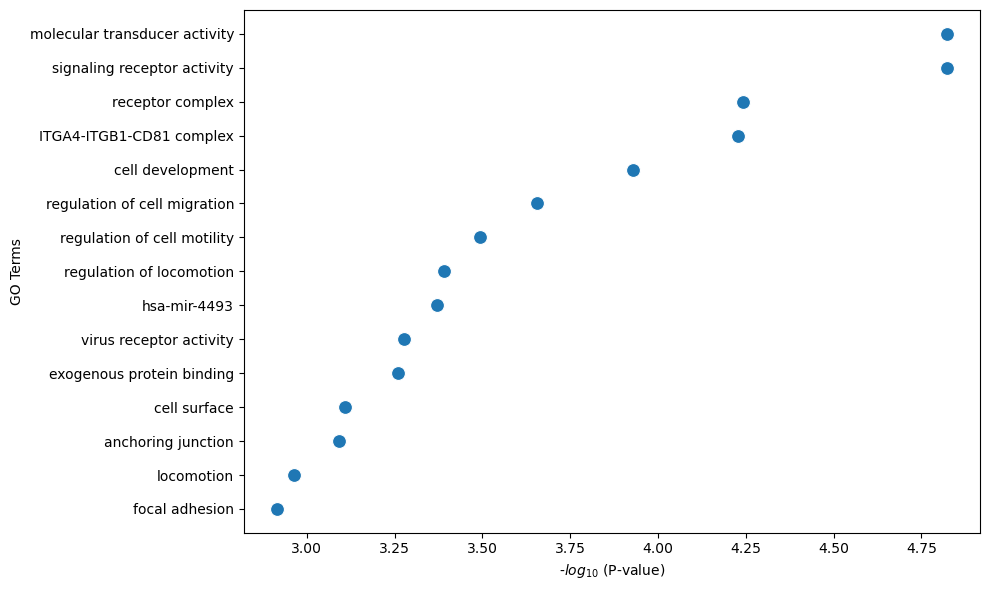

In [8]:
top_listener_CTR_ggi_genes = list(i.split('|')[0].split('/')[1] for i in rankings_table_ctr_tail['nodes'])
top_listener_EXP_ggi_genes = list(i.split('|')[0].split('/')[1] for i in rankings_table_exp_tail['nodes'])

ctpl.plot.gene_annotation(gene_list_to_profile=top_listener_CTR_ggi_genes,
                          num_gos=15,
                          figsize=(10,6))



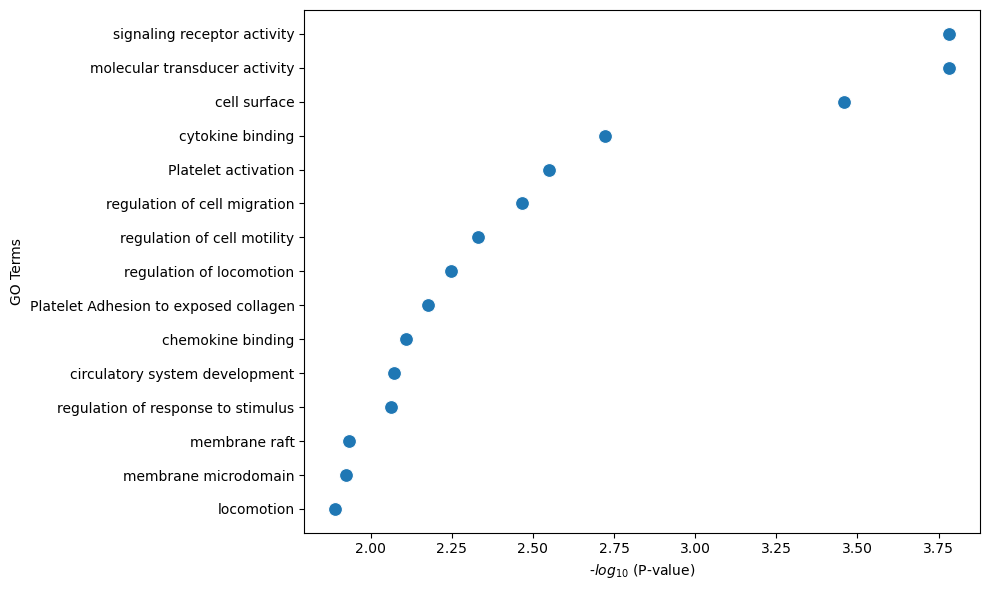

In [25]:
ctpl.plot.gene_annotation(gene_list_to_profile=top_listener_EXP_ggi_genes,
                          num_gos=15,
                          figsize=(10,6))

It is possible to perform further analysis on the gene-gene-level regarding the other topological measures, but we focus on the result of these more in the condition comparison results described in the next section.

### Compared Condition Results

pyCrossTalkeR not only analyzes the conditions individually but also calculates the differences in the cell-cell interactions between the conditions. The results of these analyses are presented in the comparative report. In our example we compare the disease (EXP) against the control (CTR) condition.

#### Cell-Cell-Interaction analysis results

As before for the single condition results, the first part of the results deal with cell-cell interactions. Here we show again the CCI graph plot, but now for the compared conditions:

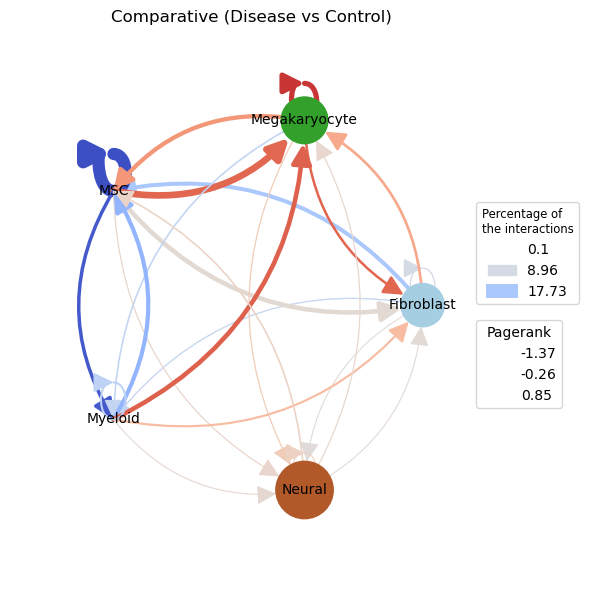

In [27]:
ctpl.plot.plot_cci(graph=adata.uns['pycrosstalker']['results']["graphs"]["EXP_x_CTR"],
        colors=adata.uns['pycrosstalker']['results']["colors"],
        plt_name='Comparative (Disease vs Control)',
        coords=adata.uns['pycrosstalker']['results']["coords"],
        emax= None,
        leg= False,
        low= 0,
        high= 0, 
        ignore_alpha= False,
        log= False,
        efactor= 8,
        vfactor= 12, 
        pg= adata.uns['pycrosstalker']['results']["rankings"]["EXP_x_CTR"]["Pagerank"]
        )

The main difference from the previous CCI graph plots is that the edge weights can now be not only positive but also negative, as well as the Pagerank values of the nodes. Positive values mean that these interactions between cell types have a higher activity/importance in the EXP condition, while negative values indicate a lower activity/importannce in the EXP condition (higher in CTR). As we can see in the CCI plot above, there are equally positive and negative edge weights present. The edge weights between MSCs and Megakaryocytes are positive up in both directions in the Disease condition. Thus, we can conclude that the communication is stronger in the EXP example. In contrast, the edge weights between the MSC and Myeloid nodes have negative edge weights, meaning these communication are lower in the EXP condition. Further, the self communication edge of the MSC node has a strong negative weight and also the pagerank is very small (indicated by small node size). This indicates that MSCs are more important in the CCIs in the CTR condition.

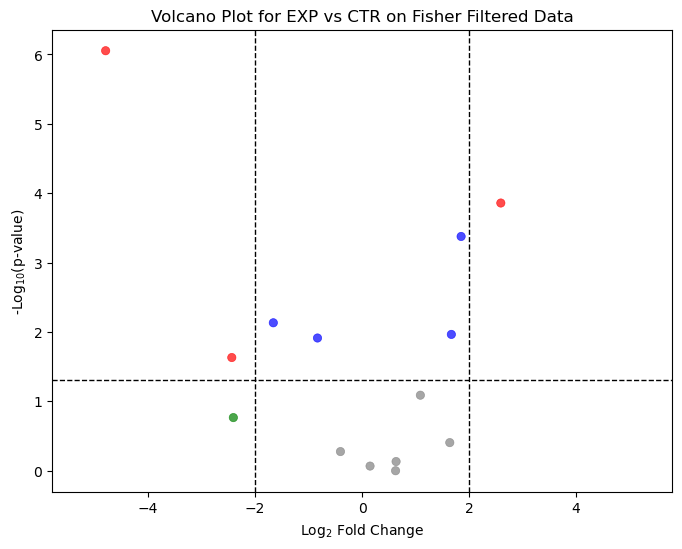

In [11]:
ctpl.plot_volcane(adata.uns['pycrosstalker']['results']['stats']['EXP_x_CTR'], "fisher", 0.05, 2, annot=False, title="Volcano Plot for EXP vs CTR on Fisher Filtered Data")

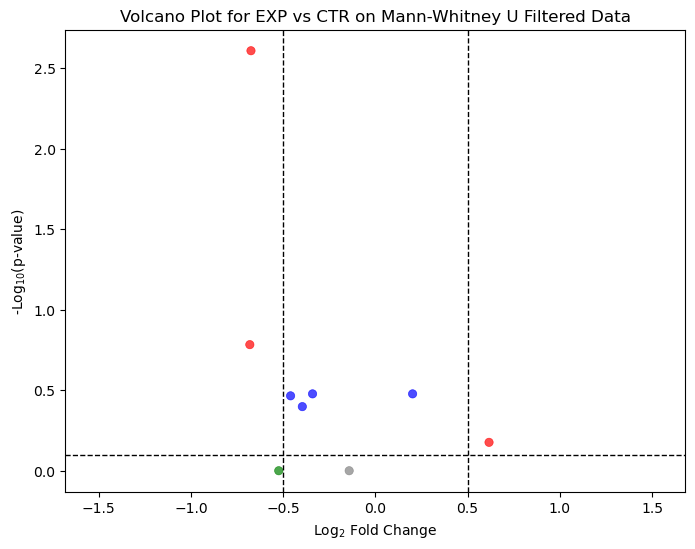

In [12]:
ctpl.plot_volcane(adata.uns['pycrosstalker']['results']['stats']['EXP_x_CTR:MannU'], "mannwhitneyu", p_threshold=0.8, fc_threshold=0.5, annot = False, title="Volcano Plot for EXP vs CTR on Mann-Whitney U Filtered Data")

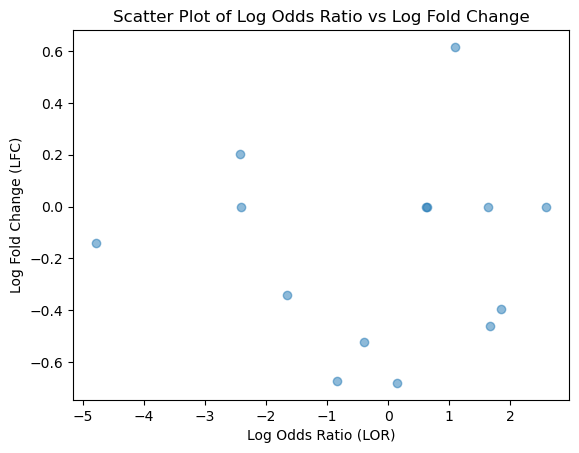

In [13]:
x = adata.uns['pycrosstalker']['results']['stats']['EXP_x_CTR']
y = adata.uns['pycrosstalker']['results']['stats']['EXP_x_CTR:MannU']

merged = pd.merge(x, y, on='cellpair', how='outer').fillna(0)

plt.scatter(merged['lodds'], merged['lfc'], alpha=0.5)
plt.ylabel('Log Fold Change (LFC)')
plt.xlabel('Log Odds Ratio (LOR)')
plt.title('Scatter Plot of Log Odds Ratio vs Log Fold Change')
plt.show()

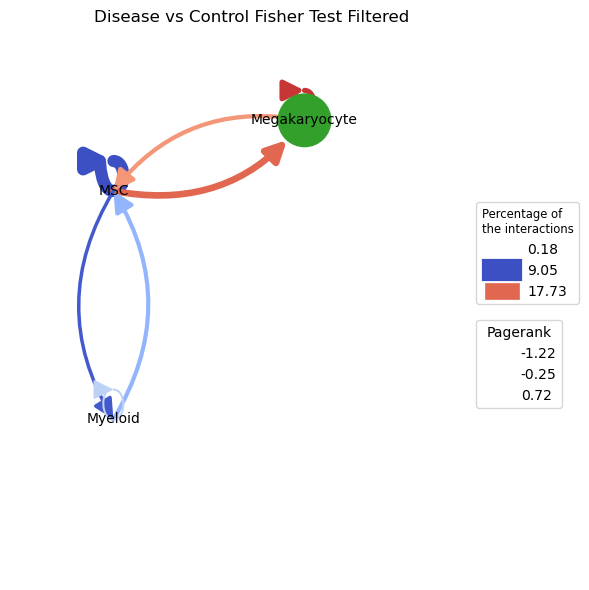

In [28]:
ctpl.plot.plot_cci(graph=adata.uns['pycrosstalker']['results']["graphs"]["EXP_x_CTR_filtered"],
        colors=adata.uns['pycrosstalker']['results']["colors"],
        plt_name='Disease vs Control Fisher Test Filtered',
        coords=adata.uns['pycrosstalker']['results']["coords"],
        emax= None,
        leg= False,
        low= 0,
        high= 0, 
        ignore_alpha= False,
        log= False,
        efactor= 8,
        vfactor= 12, 
        pg= adata.uns['pycrosstalker']['results']["rankings"]["EXP_x_CTR_filtered"]["Pagerank"]
        )

pyCrossTalkeR offers a refined CCI graph by employing Fisher’s exact test to filter the network based on interaction proportions. In this small example, the interactions with Fibroblasts and Neural cells are removed from the network applying the tests results. The before described interactions between MSCs, Megakaryocytes and Myeloid cells are still retained, further indicating the importance in the communication. Since this example data is small, we going to continue using the unfiltered network in the following steps. The filtered CCI graph is mostly helpful for large communication networks.

Since we have created a CCI network we can also analyze it based on topological properties to identify possible biologically relevant processes. For this purpose, the same topological measures can be used that are present in the single condition results for gene-cell interactions analysis (Influencer, Listener, Mediator, Pagerank). As before, we can look at the rankings individually in the form of bar plots. Here is an example for the Pagerank of cell types in the network:

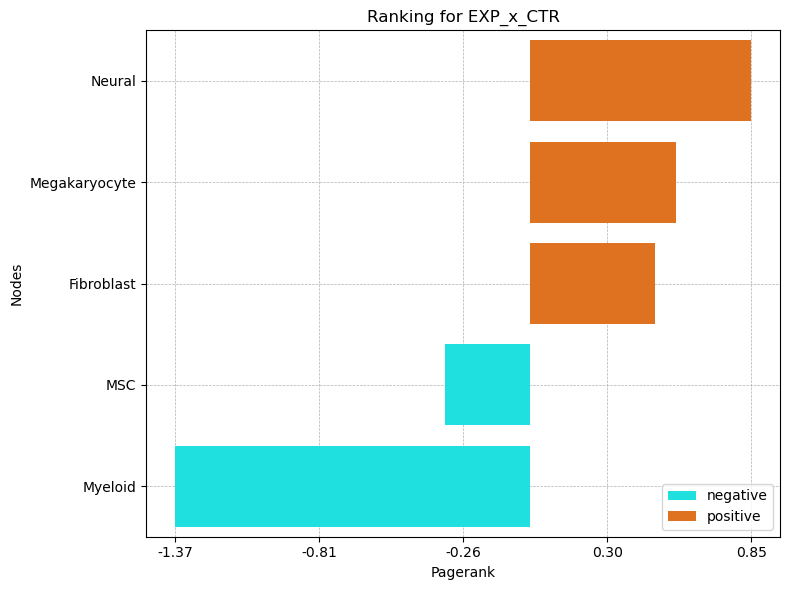

In [15]:
ctpl.plot_bar_rankings(adata, "EXP_x_CTR", "Pagerank")

In our comparison, the Neural cells have the highest pagerank, which suggest a high importance in our network for the EXP condition. In the negative direction, Myeloid cells has the lowest Pagerank. This suggest a higher importance in the CTR condition. By considering now also the other topological measures, we can assign/find other communication properties of the cell types:

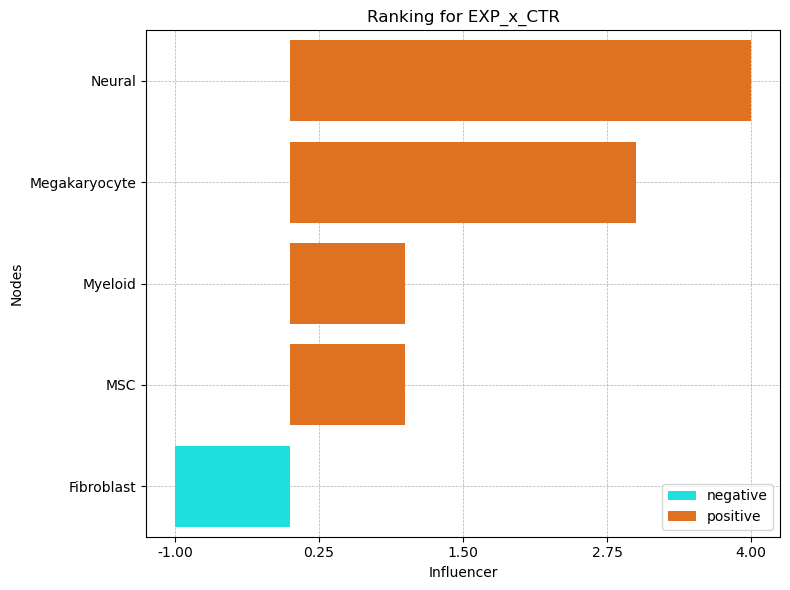

In [16]:
ctpl.plot_bar_rankings(adata, "EXP_x_CTR", "Influencer")

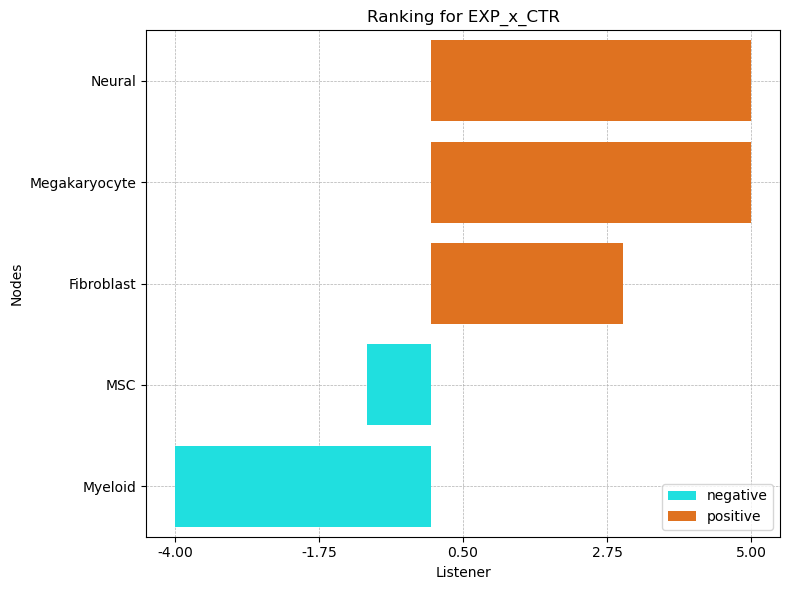

In [17]:
ctpl.plot_bar_rankings(adata, "EXP_x_CTR", "Listener")

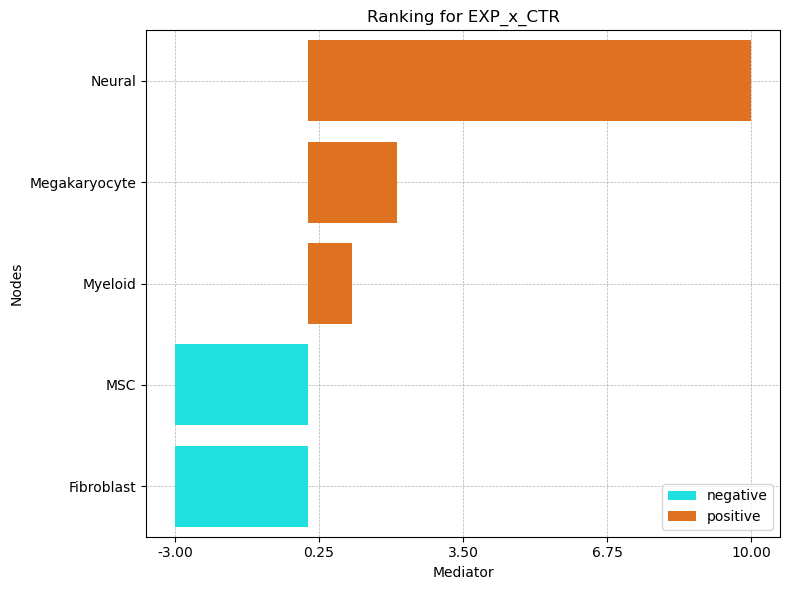

In [18]:
ctpl.plot_bar_rankings(adata, "EXP_x_CTR", "Mediator")

Including the Influencer, Listener and Mediator barplots reveals that Neural cells have the highest PageRank, Influencer, and Listener scores, indicating they engage in the most significant interactions in the EXP condition. However, their Mediator score is negative, suggesting a stronger mediating role in the CTR condition.

In contrast, Myeloid cells show high negative scores across most metrics except for the Influencer score, emphasizing their importance in the CTR condition. These findings highlight the differing roles of these cell types in EXP versus normal states.

### Cell-Gene-Interaction Analysis Results

The second part of the report deals again with the interactions on the gene level. Here, the procedure is similar to the one described in the last section for the cell-cell interactions and the analysis performed for the single conditions. First of all, we can look at the results of the topological rankings in the form of bar plots, again using the example of the pagerank:

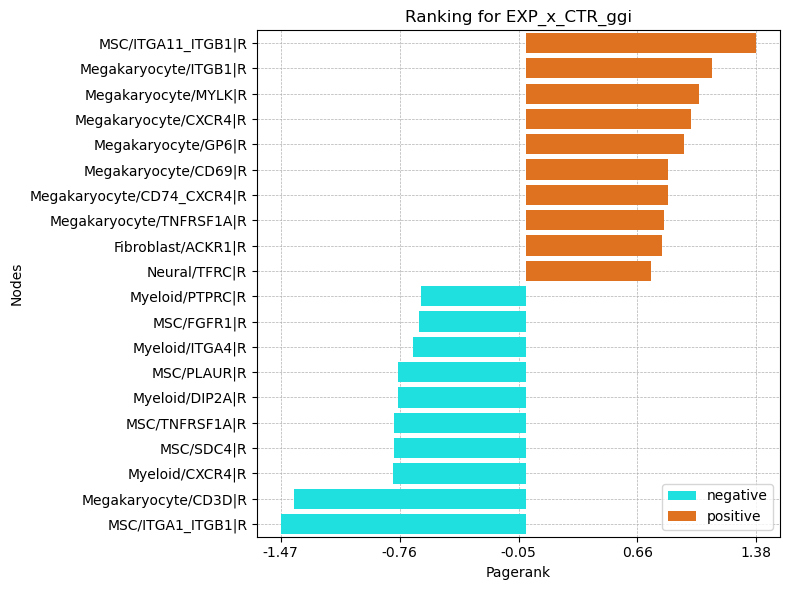

In [19]:
ctpl.plot_bar_rankings(adata, "EXP_x_CTR_ggi", "Pagerank", type="LR", mode = "cgi")

The plot highlights the ligand and receptor genes that play significant roles in different conditions. Notably, the top genes in both positive and negative directions are predominantly receptor genes. Specifically, the majority of positively scored genes are receptor genes from Megakaryocytes, while the top negatively scored genes are associated with Myeloid cells.

Among the key receptors, ITGB1 is upregulated in Megakaryocytes, while ITGA1 is downregulated in MSCs. Additionally, the score of CXCR4 is also elevated in Megakaryocytes. For further insights, we encourage examining the other rankings. Given that we are focusing on pairwise interactions, our analysis will concentrate on the Influencer and Listener rankings:

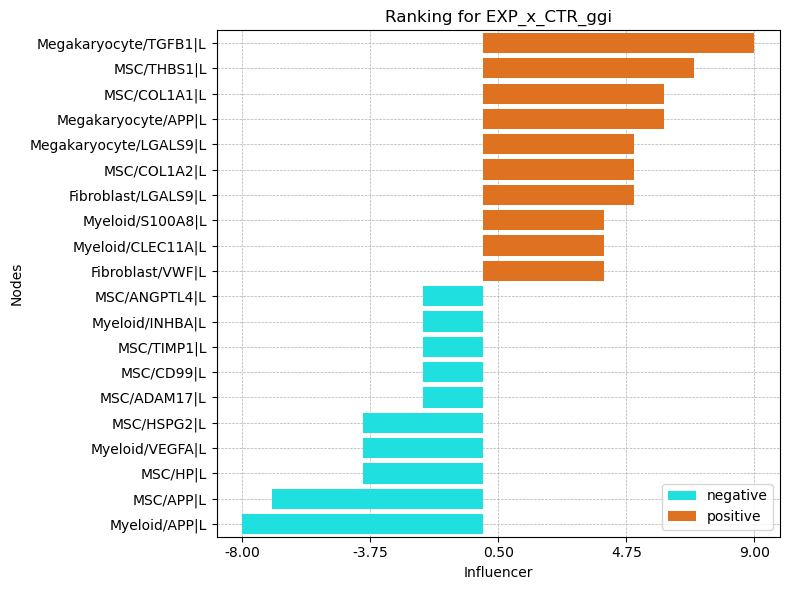

In [20]:
ctpl.plot_bar_rankings(adata, "EXP_x_CTR_ggi", "Influencer", type="LR", mode = "cgi")

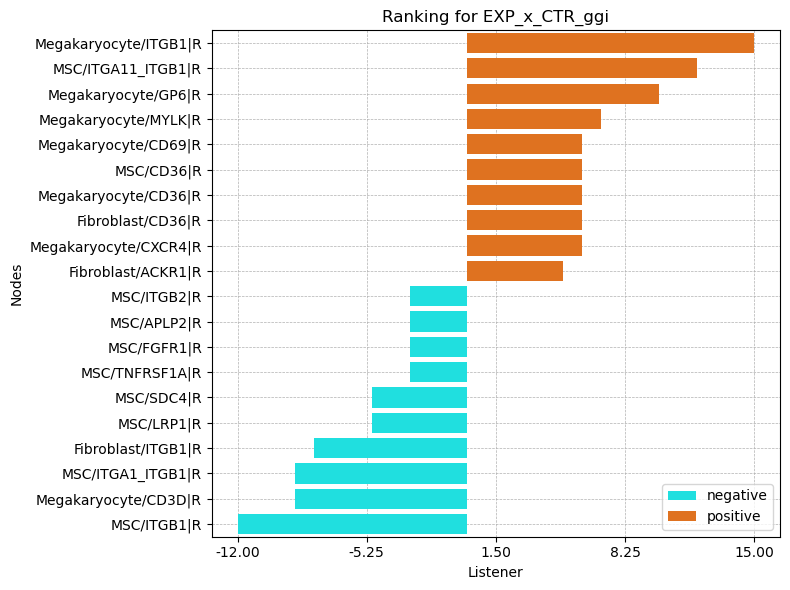

In [21]:
ctpl.plot_bar_rankings(adata, "EXP_x_CTR_ggi", "Listener", type = "LR", mode = "cgi")

The top Influencer in EXP condition identified is TGFB1 in Megakaryocytes. Also COL1A1 and COL1A2 from MSCs rank high on the positive side. CXCL12 from MSCs as example has a negative Influencer ranking. In the Listener category, integrin receptors dominate, but there are also receptors as CXCR4 and LRP1 ranking high/low.

### Follow-up Analysis

Since we got a first impression of the data with the previous results, we can further deepen the analysis. For example, we had TGFB1 in Megakaryocytes, ITGB1 in Megakaryocytes, Fibroblasts and MSCs and CXCR4 in Megakaryocytes and Myeloid cells as interesting genes. With pyCrossTalkeR, we can look even more closely at the interactions involving these genes using Sankey plots. There are two ways to do this. First, we can regenerate the report again, this time passing a list of genes of interest. The second option is to plot only the Sankey plots for the genes of interests, without redoing the report:

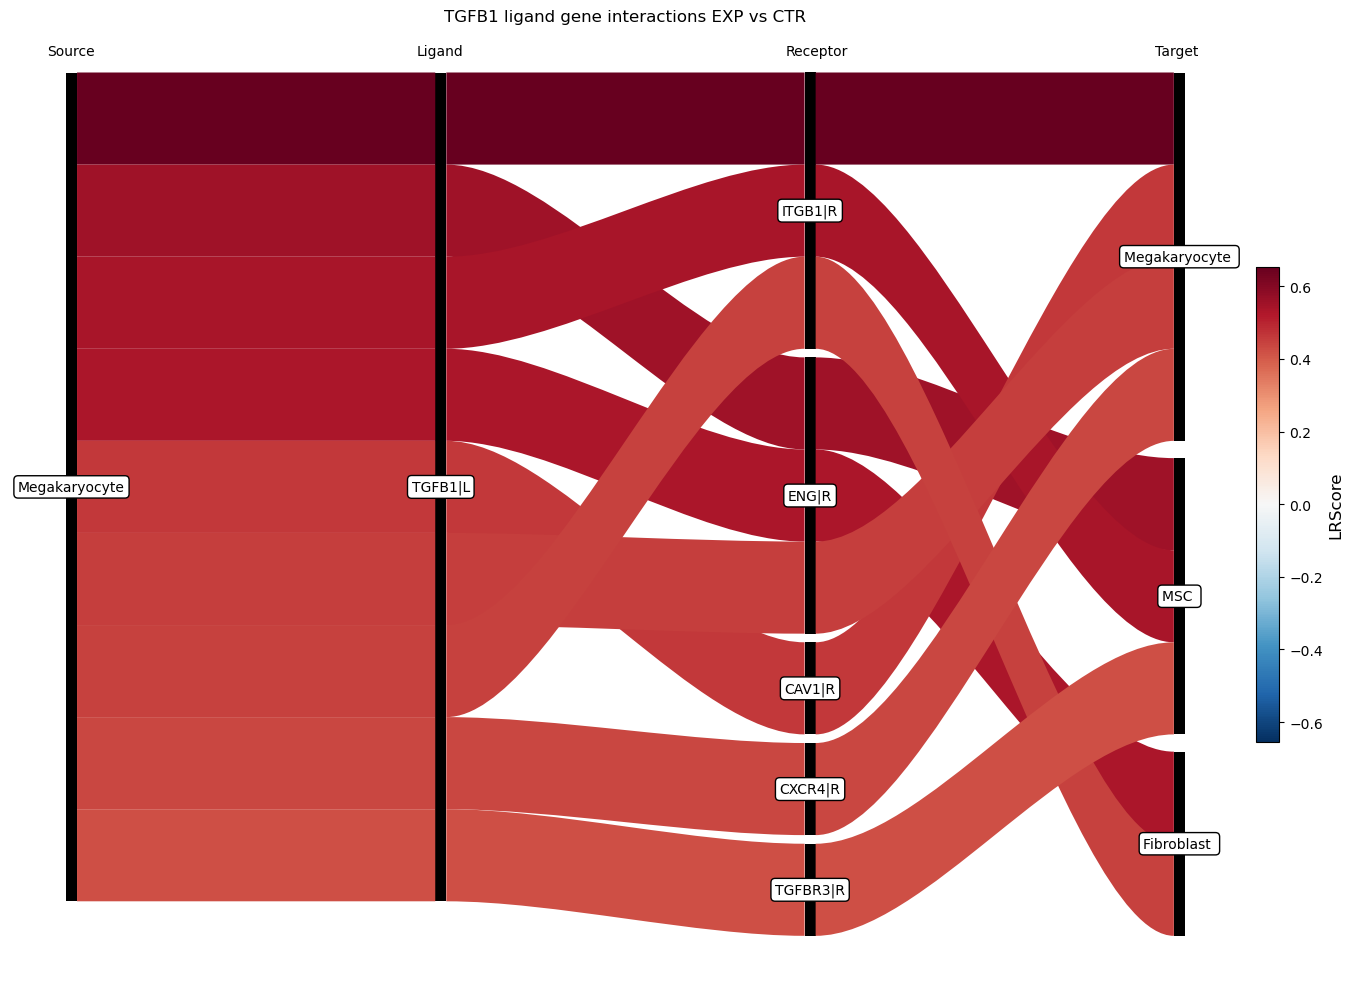

In [22]:
ctpl.plot_sankey(
    adata.uns['pycrosstalker']['results']['tables']['EXP_x_CTR'], 
    target = "TGFB1|L",
    plt_name = "TGFB1 ligand gene interactions EXP vs CTR",
    threshold = 50)

In the Sankey plot, not all interactions involving the TGFB1 ligand gene are shown, but only those with a high score. The number of actual interactions can be controlled with the threshold parameter. In the example above 50 interactions are selected. Since we have only entered one target gene without any further information, we can now also see interactions originating from different cell types, here Fibroblasts, Megakaryocytes and MSCs. Furthermore, we now have a list of receptors with associated cell types with which the TGFB1 ligand can possibly interact. The list also includes the receptor ITGB1 in Megakaryocytes, which was also a gene of interest. The interaction between TGFB1 and ITGB1 has a positive score, which means it is enriched in the EXP condition.

The third gene of interest was the receptor gene CXCR4 with a high importance in Megakaryocytes in the EXP condition and in Myeloid cells in the CTR condition. If we want to focus only on CXCR4 in Megakaryocytes and Myeloid cells, we can define a receptor_cluster value when running the Sankey plot function. Also, the number of interactions included is reduced by setting the threshold parameter to 15.

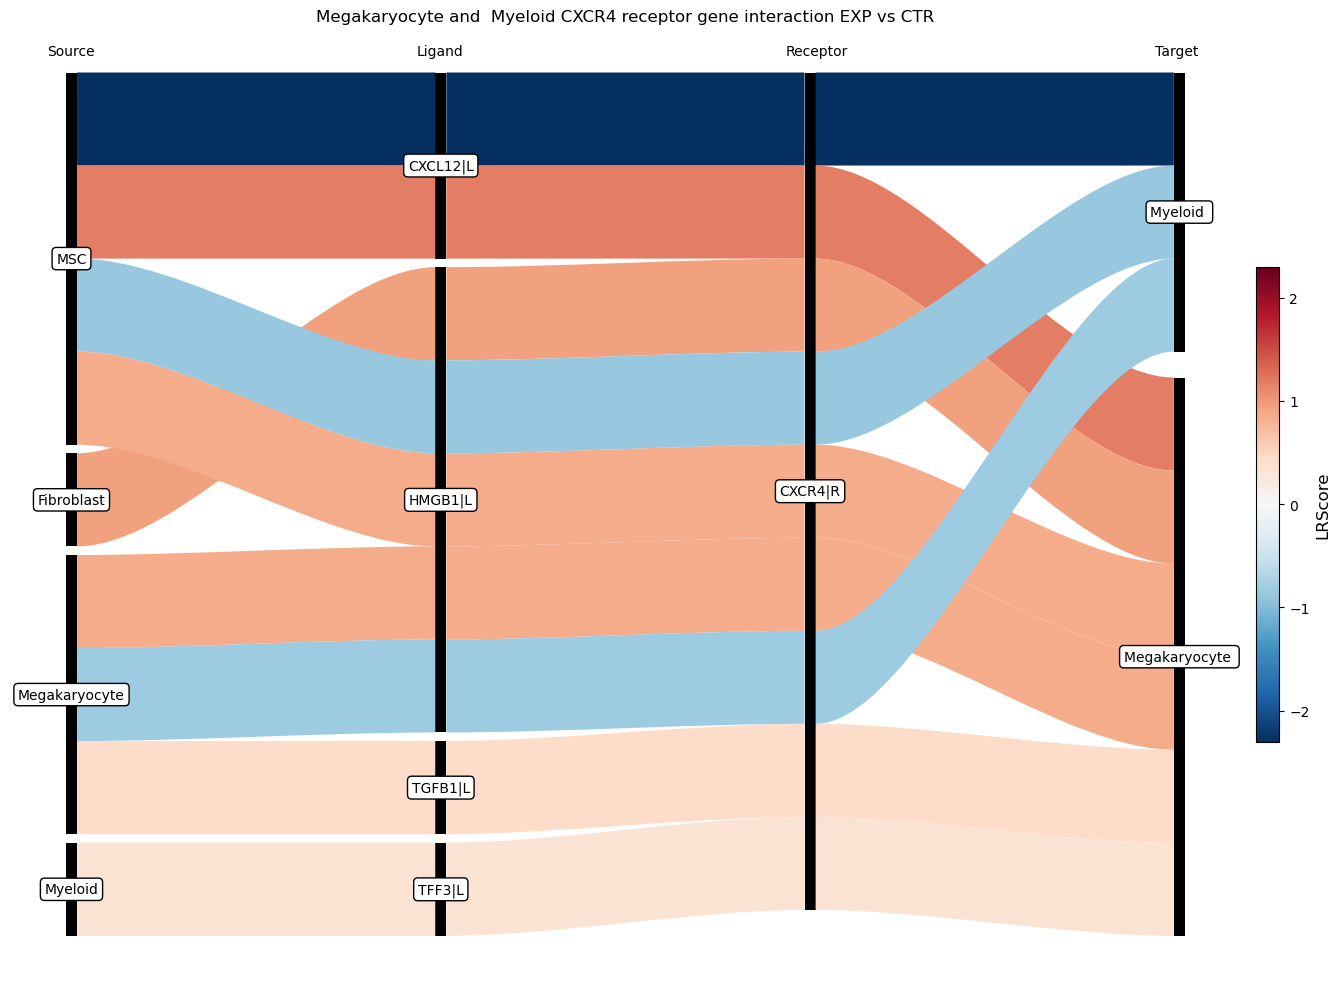

In [23]:
ctpl.plot_sankey(
    adata.uns['pycrosstalker']['results']['tables']['EXP_x_CTR'],
    target = "CXCR4|R",
    receptor_cluster = ["Megakaryocyte", "Myeloid"],
    plt_name = "Megakaryocyte and  Myeloid CXCR4 receptor gene interaction EXP vs CTR",
    threshold = 15)


The Sankey plot confirms that the LR Score indicates higher interaction with CXCR4 in Megakaryocytes under EXP condition and in Myeloid cells under CTR condition. Additionally, it highlights previously occuring ligand and receptors, including TGFB ligand from Megakaryocytes to CXCR4 in Megakaryocytes and CXCL12 from MSCs to CXCR4 in both Megakaryocytes and Myeloid cells.

Another interesting target described in by [Leimkühler et. al. 2021](https://www.sciencedirect.com/science/article/pii/S1934590920305427?via%3Dihub) is the ligand S100A8. The study also shows that when S100A8 is targeted the MPN phenotype is ameliorated.

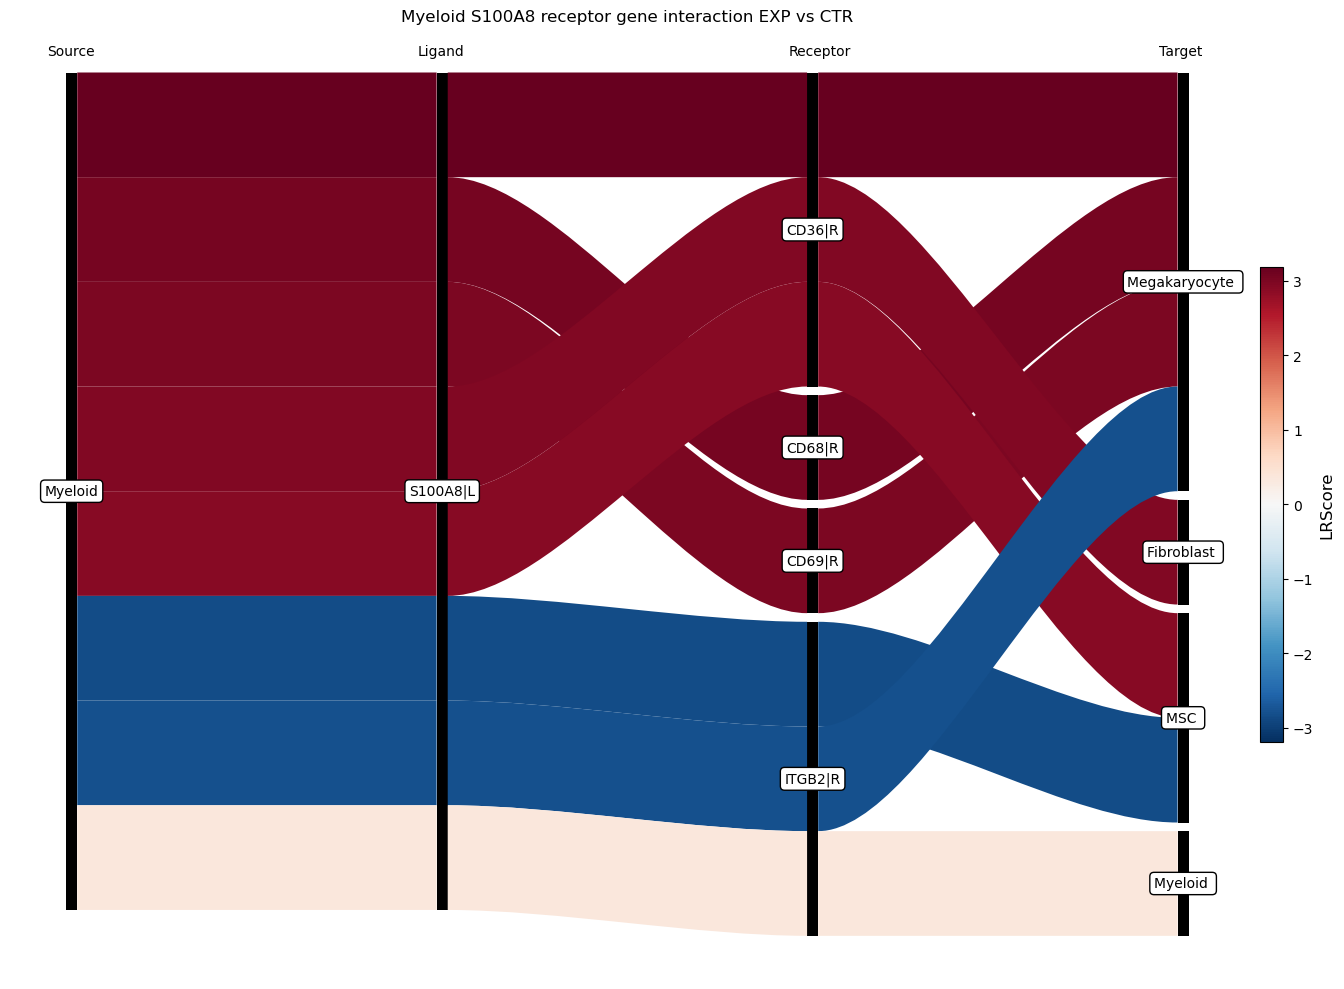

In [24]:
ctpl.plot_sankey(
    adata.uns['pycrosstalker']['results']['tables']['EXP_x_CTR'],
    target = "S100A8|L",
    plt_name = "Myeloid S100A8 receptor gene interaction EXP vs CTR",
    threshold = 15)